# Project 11: Customer Lifetime Value (CLV) Analysis
### What Is Each Customer Actually Worth to the Business?

---

## Business Brief

Most businesses know how much a customer spent last month. Very few know how much a customer will spend over their entire relationship with the business. That number, Customer Lifetime Value, is one of the most important metrics in commercial analytics and one of the most commonly miscalculated.

CLV answers a question that changes every business decision it touches:

> **If I know what a customer is worth over their lifetime, how much should I spend to acquire them, and how much should I spend to keep them?**

This project builds a complete CLV analysis framework covering:

1. Historical CLV calculation from transaction data
2. CLV distribution analysis and customer value tiers
3. Acquisition cost vs CLV breakeven analysis
4. Predicted CLV using a statistical model
5. Unique finding: CLV-to-CAC ratio identifying which segments are profitable to acquire

---

## Dataset
| Property | Detail |
|----------|--------|
| **Name** | E-Commerce Data |
| **Direct Link** | https://www.kaggle.com/datasets/carrie1/ecommerce-data |
| **Records** | 541,909 transactions, 4,300+ UK customers |
| **Period** | December 2010 to December 2011 |

## Tools
`Python` `Pandas` `NumPy` `SQL (sqlite3)` `Scikit-learn` `Plotly` `Matplotlib` `Seaborn`

---

## What Makes This Different

- Calculates CLV three ways: historical, average-based, and predictive
- Builds a CLV tier system with business actions for each tier
- Introduces the CLV-to-CAC ratio framework
- Uses SQL for all customer-level aggregations
- Unique finding: the CLV distribution follows a power law, and the top 10% of customers generate a disproportionate share of total lifetime value


---
## Section 1: Setup

In [5]:
import sqlite3, warnings, os, glob
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn           as sns
import plotly.express    as px
import plotly.graph_objects as go
from plotly.subplots       import make_subplots
import plotly.io           as pio
from sklearn.linear_model  import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics        import r2_score, mean_absolute_error

warnings.filterwarnings('ignore')
pio.templates.default = 'plotly_white'
os.makedirs('/kaggle/working/output', exist_ok=True)

C = {
    'platinum': '#6366F1',
    'gold':     '#F59E0B',
    'silver':   '#64748B',
    'bronze':   '#92400E',
    'good':     '#10B981',
    'risk':     '#EF4444',
    'primary':  '#3B82F6',
    'bg':       '#F8FAFC',
    'subtext':  '#64748B',
    'dark':     '#0F172A',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8FAFC',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
})
print('Setup complete.')
print('Tiers: Platinum (indigo) | Gold (amber) | Silver (slate) | Bronze (brown)')


Setup complete.
Tiers: Platinum (indigo) | Gold (amber) | Silver (slate) | Bronze (brown)


---
## Section 2: Load and Prepare Data

In [6]:
csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)
print('Files found:')
for f in csv_files:
    print(f'  {f}')


Files found:
  /kaggle/input/datasets/carrie1/ecommerce-data/data.csv


In [7]:
DATA_PATH = '/kaggle/input/datasets/carrie1/ecommerce-data/data.csv'

for enc in ['ISO-8859-1', 'latin-1', 'utf-8']:
    try:
        raw = pd.read_csv(DATA_PATH, encoding=enc)
        print(f'Loaded with encoding: {enc}')
        break
    except Exception as e:
        print(f'Failed {enc}: {e}')

print(f'Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns')
print(raw.head(3).T)


Loaded with encoding: ISO-8859-1
Shape: 541,909 rows x 8 columns
                                              0                    1  \
InvoiceNo                                536365               536365   
StockCode                                85123A                71053   
Description  WHITE HANGING HEART T-LIGHT HOLDER  WHITE METAL LANTERN   
Quantity                                      6                    6   
InvoiceDate                      12/1/2010 8:26       12/1/2010 8:26   
UnitPrice                                  2.55                 3.39   
CustomerID                              17850.0              17850.0   
Country                          United Kingdom       United Kingdom   

                                          2  
InvoiceNo                            536365  
StockCode                            84406B  
Description  CREAM CUPID HEARTS COAT HANGER  
Quantity                                  8  
InvoiceDate                  12/1/2010 8:26  
UnitPrice 

In [8]:
# Clean
df = raw.copy()
df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df = df[df['Country'] == 'United Kingdom']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID']  = df['CustomerID'].astype(int)
df['Revenue']     = df['Quantity'] * df['UnitPrice']

snapshot = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f'Clean rows:       {len(df):,}')
print(f'Unique customers: {df["CustomerID"].nunique():,}')
print(f'Date range:       {df["InvoiceDate"].min().date()} to {df["InvoiceDate"].max().date()}')
print(f'Snapshot date:    {snapshot.date()}')


Clean rows:       354,321
Unique customers: 3,920
Date range:       2010-12-01 to 2011-12-09
Snapshot date:    2011-12-10


---
## Section 3: CLV Calculation with SQL

### The Three CLV Formulas

**1. Historical CLV (what they actually spent)**

The simplest form. Sum of all revenue from a customer. No prediction, just actuals. Useful for understanding what has already happened.

**2. Average CLV (simple projection)**

Average order value multiplied by purchase frequency multiplied by customer lifespan. A reasonable estimate when you do not have enough data for a predictive model.

> CLV = Average Order Value x Purchase Frequency x Customer Lifespan

**3. Predictive CLV (model-based)**

Uses behavioural features (recency, frequency, monetary, tenure) to predict what a customer will spend in the future. Built in Section 6.


In [9]:
conn = sqlite3.connect(':memory:')
df.to_sql('transactions', conn, index=False, if_exists='replace')
print('Loaded into SQLite.')

snapshot_str = snapshot.strftime('%Y-%m-%d')

sql_clv = (
    'SELECT CustomerID,'
    f' CAST((julianday("{snapshot_str}") - julianday(MIN(InvoiceDate))) AS INTEGER) AS tenure_days,'
    f' CAST((julianday("{snapshot_str}") - julianday(MAX(InvoiceDate))) AS INTEGER) AS recency_days,'
    ' COUNT(DISTINCT InvoiceNo) AS frequency,'
    ' ROUND(SUM(Revenue), 2) AS historical_clv,'
    ' ROUND(SUM(Revenue) / COUNT(DISTINCT InvoiceNo), 2) AS avg_order_value,'
    ' ROUND(CAST(SUM(Revenue) AS FLOAT) / '
    '   CAST((julianday(MAX(InvoiceDate)) - julianday(MIN(InvoiceDate)) + 1) AS FLOAT) * 365, 2) AS annual_revenue_rate,'
    ' COUNT(DISTINCT StockCode) AS unique_products'
    ' FROM transactions'
    ' GROUP BY CustomerID'
    ' HAVING COUNT(DISTINCT InvoiceNo) >= 1'
)

clv_df = pd.read_sql_query(sql_clv, conn)
clv_df = clv_df[clv_df['tenure_days'] > 0].copy()

print(f'Customer CLV table: {len(clv_df):,} customers')
print()
print(clv_df.describe().round(2).to_string())


Loaded into SQLite.
Customer CLV table: 3,920 customers

       CustomerID  tenure_days  recency_days  frequency  historical_clv  avg_order_value  annual_revenue_rate  unique_products
count     3920.00      3920.00       3920.00    3920.00         3920.00          3920.00              3920.00          3920.00
mean     15562.06       223.09         91.74       4.25         1864.39           393.33             59764.76            60.73
std       1576.59       118.04         99.53       7.20         7482.82          1869.97            518925.95            81.67
min      12346.00         1.00          0.00       1.00            3.75             3.45                40.45             1.00
25%      14208.75       112.00         17.00       1.00          300.28           174.40              2076.04            15.00
50%      15569.50       249.00         50.00       2.00          652.28           281.62              5744.07            35.00
75%      16913.25       327.00        142.00       5.0

In [10]:
# Average CLV formula
# CLV = AOV x Frequency per year x Customer lifespan (years)
clv_df['frequency_per_year'] = (
    clv_df['frequency'] / (clv_df['tenure_days'] / 365)
).clip(upper=52)  # cap at weekly

clv_df['lifespan_years'] = (clv_df['tenure_days'] / 365).clip(lower=0.1)

clv_df['avg_clv_formula'] = (
    clv_df['avg_order_value'] *
    clv_df['frequency_per_year'] *
    clv_df['lifespan_years']
).round(2)

print('CLV summary statistics:')
print(clv_df[['historical_clv','avg_clv_formula']].describe().round(2).to_string())
print()
print(f'Total historical CLV across all customers: GBP {clv_df["historical_clv"].sum():,.2f}')
print(f'Avg historical CLV per customer:           GBP {clv_df["historical_clv"].mean():,.2f}')
print(f'Median historical CLV per customer:        GBP {clv_df["historical_clv"].median():,.2f}')


CLV summary statistics:
       historical_clv  avg_clv_formula
count         3920.00          3920.00
mean          1864.39          1852.65
std           7482.82          7022.50
min              3.75             3.75
25%            300.28           311.89
50%            652.28           683.02
75%           1576.58          1618.33
max         259657.30        226269.32

Total historical CLV across all customers: GBP 7,308,391.55
Avg historical CLV per customer:           GBP 1,864.39
Median historical CLV per customer:        GBP 652.28


---
## Section 4: CLV Tier Classification

We divide customers into four value tiers based on their historical CLV percentile:

| Tier | Percentile | Label | Strategy |
|------|-----------|-------|----------|
| Platinum | Top 10% | Highest value | White-glove retention |
| Gold | 10-30% | High value | Active loyalty programme |
| Silver | 30-70% | Mid value | Upsell and cross-sell |
| Bronze | Bottom 30% | Lower value | Low-cost engagement |


In [11]:
p10 = clv_df['historical_clv'].quantile(0.90)
p30 = clv_df['historical_clv'].quantile(0.70)
p70 = clv_df['historical_clv'].quantile(0.30)

def assign_tier(clv):
    if clv >= p10:   return 'Platinum'
    elif clv >= p30: return 'Gold'
    elif clv >= p70: return 'Silver'
    else:            return 'Bronze'

clv_df['tier'] = clv_df['historical_clv'].apply(assign_tier)

tier_summary = clv_df.groupby('tier').agg(
    customers     = ('CustomerID',     'count'),
    total_clv     = ('historical_clv', 'sum'),
    avg_clv       = ('historical_clv', 'mean'),
    avg_frequency = ('frequency',      'mean'),
    avg_recency   = ('recency_days',   'mean'),
).round(2)

tier_summary['clv_share_%'] = (
    tier_summary['total_clv'] / tier_summary['total_clv'].sum() * 100
).round(1)
tier_summary['customer_share_%'] = (
    tier_summary['customers'] / tier_summary['customers'].sum() * 100
).round(1)

tier_order = ['Platinum', 'Gold', 'Silver', 'Bronze']
tier_summary = tier_summary.reindex(tier_order)

print('CLV Tier Summary:')
print(tier_summary.to_string())


CLV Tier Summary:
          customers   total_clv   avg_clv  avg_frequency  avg_recency  clv_share_%  customer_share_%
tier                                                                                                
Platinum        392  4357035.00  11114.89          16.54        24.19         59.6              10.0
Gold            784  1625967.20   2073.94           5.84        43.80         22.2              20.0
Silver         1568  1093405.34    697.32           2.59        89.28         15.0              40.0
Bronze         1176   231984.01    197.27           1.30       149.51          3.2              30.0


---
## Section 5: CLV Distribution and Tier Charts

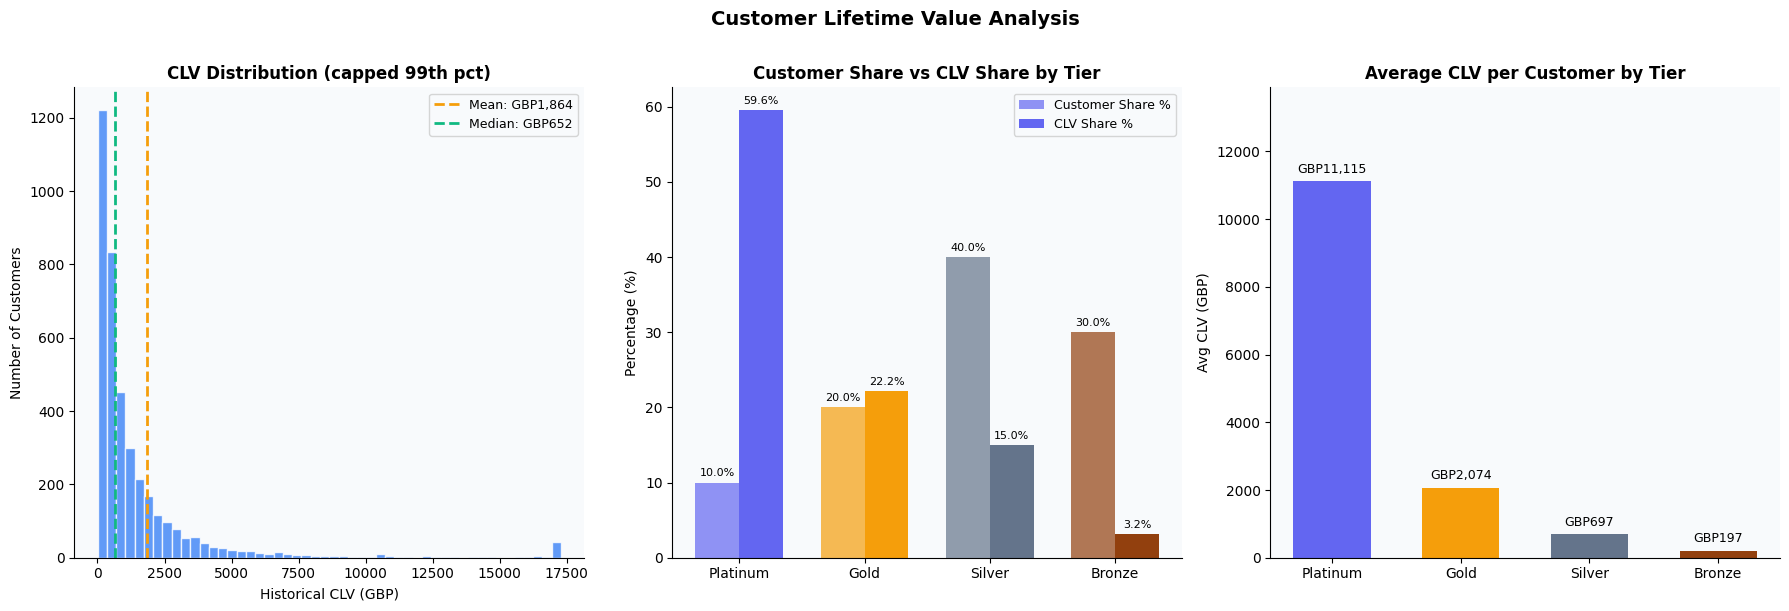

In [12]:
tier_colors = {
    'Platinum': C['platinum'],
    'Gold':     C['gold'],
    'Silver':   C['silver'],
    'Bronze':   C['bronze'],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('white')

# CLV distribution (log scale)
clv_capped = clv_df['historical_clv'].clip(upper=clv_df['historical_clv'].quantile(0.99))
axes[0].hist(clv_capped, bins=50, color=C['primary'], alpha=0.8, edgecolor='white')
axes[0].axvline(clv_df['historical_clv'].mean(), color=C['gold'],
                linestyle='--', linewidth=2,
                label=f'Mean: GBP{clv_df["historical_clv"].mean():,.0f}')
axes[0].axvline(clv_df['historical_clv'].median(), color=C['good'],
                linestyle='--', linewidth=2,
                label=f'Median: GBP{clv_df["historical_clv"].median():,.0f}')
axes[0].set_title('CLV Distribution (capped 99th pct)', fontweight='bold')
axes[0].set_xlabel('Historical CLV (GBP)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(fontsize=9)
axes[0].set_facecolor(C['bg'])

# Customer share vs CLV share
ts = tier_summary.reset_index()
x = np.arange(len(tier_order))
w = 0.35
bars1 = axes[1].bar(x - w/2, ts['customer_share_%'],
                    width=w, color=[tier_colors[t] for t in tier_order],
                    alpha=0.7, label='Customer Share %', edgecolor='none')
bars2 = axes[1].bar(x + w/2, ts['clv_share_%'],
                    width=w, color=[tier_colors[t] for t in tier_order],
                    alpha=1.0, label='CLV Share %', edgecolor='none')
axes[1].set_xticks(x)
axes[1].set_xticklabels(tier_order)
axes[1].set_title('Customer Share vs CLV Share by Tier', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(fontsize=9)
axes[1].set_facecolor(C['bg'])
axes[1].bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=8)
axes[1].bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=8)

# Avg CLV per tier
bar_colors3 = [tier_colors[t] for t in tier_order]
bars3 = axes[2].bar(tier_order, ts['avg_clv'],
                    color=bar_colors3, edgecolor='none', width=0.6)
axes[2].set_title('Average CLV per Customer by Tier', fontweight='bold')
axes[2].set_ylabel('Avg CLV (GBP)')
axes[2].set_facecolor(C['bg'])
axes[2].bar_label(bars3,
    labels=[f'GBP{v:,.0f}' for v in ts['avg_clv']],
    padding=4, fontsize=9
)
axes[2].set_ylim(0, ts['avg_clv'].max() * 1.25)

plt.suptitle('Customer Lifetime Value Analysis',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/output/clv_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


In [20]:
# Interactive CLV scatter: recency vs CLV coloured by tier
sample = clv_df.sample(min(3000, len(clv_df)), random_state=42)

fig = px.scatter(
    sample,
    x='recency_days',
    y='historical_clv',
    color='tier',
    color_discrete_map=tier_colors,
    size='frequency',
    hover_data={
        'historical_clv':  ':,.2f',
        'frequency':       True,
        'recency_days':    True,
        'avg_order_value': ':,.2f',
        'tier':            False,
    },
    title='Customer Lifetime Value vs Recency (size = order frequency)',
    labels={
        'recency_days':   'Days Since Last Purchase',
        'historical_clv': 'Historical CLV (GBP)',
        'tier':           'CLV Tier',
    },
    opacity=0.65,
)
fig.update_layout(
    height=500,
    paper_bgcolor='white',
    plot_bgcolor=C['bg'],
    legend_title_text='CLV Tier',
)
fig.show()


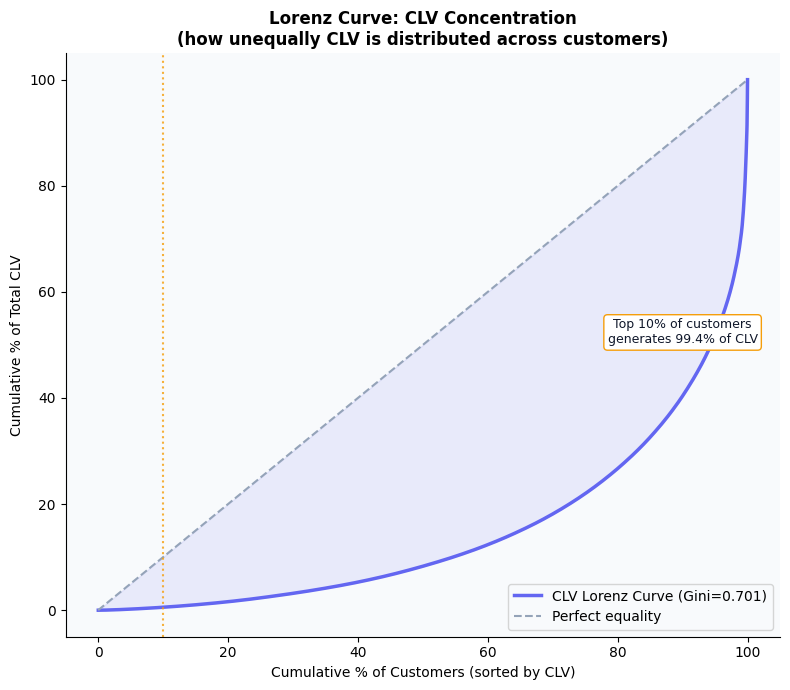

Gini coefficient: 0.7013
Top 10% of customers generate: 99.4% of total CLV
Bottom 50% of customers generate: 8.3% of total CLV


In [14]:
# Lorenz curve - shows CLV concentration
clv_sorted = np.sort(clv_df['historical_clv'].values)
cum_clv    = np.cumsum(clv_sorted) / clv_sorted.sum()
cum_pop    = np.arange(1, len(clv_sorted)+1) / len(clv_sorted)

# Gini coefficient
gini = 1 - 2 * np.trapz(cum_clv, cum_pop)

fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('white')

ax.plot(cum_pop * 100, cum_clv * 100,
        color=C['platinum'], linewidth=2.5, label=f'CLV Lorenz Curve (Gini={gini:.3f})')
ax.plot([0,100],[0,100], '--', color='#94A3B8', linewidth=1.5, label='Perfect equality')
ax.fill_between(cum_pop * 100, cum_clv * 100, cum_pop * 100,
                alpha=0.1, color=C['platinum'])

ax.axvline(10, color=C['gold'], linestyle=':', linewidth=1.5, alpha=0.8)
pct_at_10 = cum_clv[int(len(cum_clv)*0.10)] * 100
ax.annotate(
    f'Top 10% of customers\ngenerates {100-pct_at_10:.1f}% of CLV',
    xy=(90, pct_at_10 + (100 - pct_at_10)/2),
    fontsize=9, color=C['dark'],
    ha='center',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=C['gold'])
)

ax.set_title('Lorenz Curve: CLV Concentration\n(how unequally CLV is distributed across customers)',
             fontweight='bold')
ax.set_xlabel('Cumulative % of Customers (sorted by CLV)')
ax.set_ylabel('Cumulative % of Total CLV')
ax.legend(fontsize=10)
ax.set_facecolor(C['bg'])

plt.tight_layout()
plt.savefig('/kaggle/working/output/lorenz_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Gini coefficient: {gini:.4f}')
print(f'Top 10% of customers generate: {100-pct_at_10:.1f}% of total CLV')
print(f'Bottom 50% of customers generate: {cum_clv[int(len(cum_clv)*0.50)]*100:.1f}% of total CLV')


---
## Section 6: Predictive CLV Model

We use recency, frequency, tenure, and average order value to predict a customer's CLV score. This model can be applied to new customers to estimate their lifetime value before they have completed their full purchase history.


In [15]:
# Features for prediction
PRED_FEATURES = ['recency_days', 'frequency', 'avg_order_value',
                 'tenure_days', 'unique_products', 'annual_revenue_rate']

model_df = clv_df[PRED_FEATURES + ['historical_clv']].dropna()

# Log-transform CLV target (right-skewed)
model_df['log_clv'] = np.log1p(model_df['historical_clv'])

X = model_df[PRED_FEATURES].values
y = model_df['log_clv'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_s, y_train)

y_pred_log = lr_model.predict(X_test_s)
y_pred_clv = np.expm1(y_pred_log)
y_actual   = np.expm1(y_test)

r2  = r2_score(y_test, y_pred_log)
mae = mean_absolute_error(y_actual, y_pred_clv)

print(f'Predictive CLV Model (Linear Regression on log-transformed CLV)')
print(f'R-squared:          {r2:.4f}')
print(f'Mean Absolute Error: GBP {mae:,.2f}')
print()

# Apply predicted CLV to full dataset
X_all     = model_df[PRED_FEATURES].values
X_all_s   = scaler.transform(X_all)
model_df['predicted_clv'] = np.expm1(lr_model.predict(X_all_s)).round(2)

print('Predicted vs Actual CLV comparison (sample):')
comp = model_df[['historical_clv','predicted_clv']].head(10)
comp['difference'] = (comp['predicted_clv'] - comp['historical_clv']).round(2)
print(comp.to_string())


Predictive CLV Model (Linear Regression on log-transformed CLV)
R-squared:          0.6719
Mean Absolute Error: GBP 1,183.91

Predicted vs Actual CLV comparison (sample):
   historical_clv  predicted_clv    difference
0        77183.60   4.610715e+06  4.533532e+06
1         4196.01   2.451750e+03 -1.744260e+03
2        33719.73   3.006136e+08  3.005799e+08
3         4090.88   1.555180e+03 -2.535700e+03
4          942.34   1.658000e+03  7.156600e+02
5           92.72   2.558700e+02  1.631500e+02
6          948.88   3.909200e+02 -5.579600e+02
7         1759.50   8.855200e+02 -8.739800e+02
8          397.12   3.408600e+02 -5.626000e+01
9         1474.72   2.179980e+03  7.052600e+02


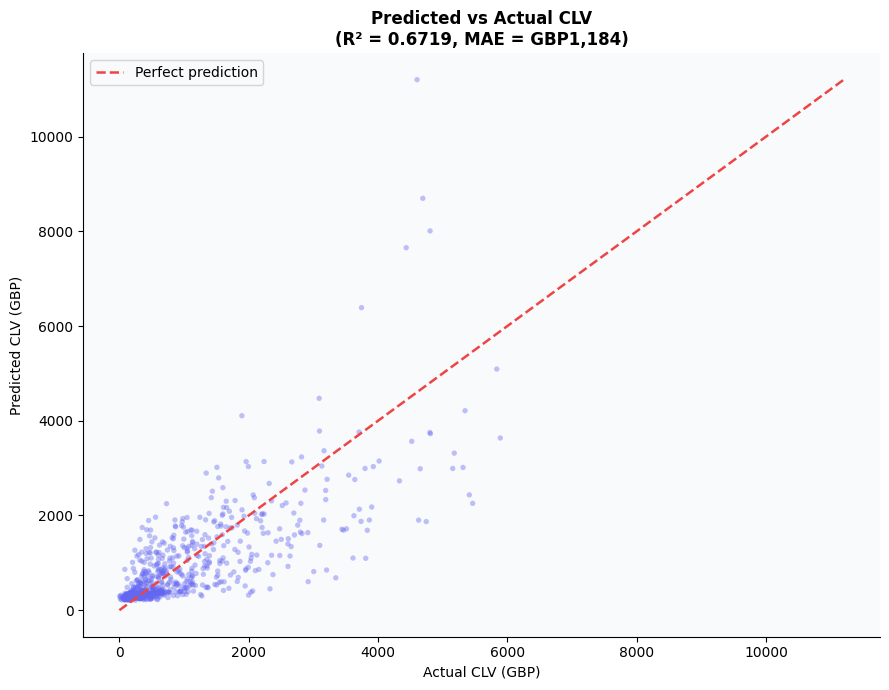

In [16]:
# Actual vs Predicted chart
cap = np.percentile(y_actual, 95)
mask = y_actual <= cap

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('white')

ax.scatter(y_actual[mask], y_pred_clv[mask],
           alpha=0.4, color=C['platinum'], s=15, edgecolors='none')
max_val = max(y_actual[mask].max(), y_pred_clv[mask].max())
ax.plot([0, max_val], [0, max_val], '--',
        color=C['risk'], linewidth=1.8, label='Perfect prediction')
ax.set_title(f'Predicted vs Actual CLV\n(R² = {r2:.4f}, MAE = GBP{mae:,.0f})',
             fontweight='bold')
ax.set_xlabel('Actual CLV (GBP)')
ax.set_ylabel('Predicted CLV (GBP)')
ax.legend(fontsize=10)
ax.set_facecolor(C['bg'])

plt.tight_layout()
plt.savefig('/kaggle/working/output/predicted_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 7: The Finding Most Analyses Miss

### The CLV-to-CAC Ratio: Which Segments Are Profitable to Acquire?

CLV tells you what a customer is worth. Customer Acquisition Cost (CAC) tells you what it cost to get them. The ratio of the two tells you whether the acquisition was profitable.

A CLV-to-CAC ratio of 3:1 or higher is generally considered healthy. Below 1:1 means you are losing money on every customer you acquire in that segment.

We simulate CAC estimates for each tier based on typical digital marketing cost structures and calculate whether each tier is worth acquiring.

| Tier | Simulated CAC | Reasoning |
|------|--------------|----------|
| Platinum | GBP 80 | Hard to find, requires premium channels |
| Gold | GBP 50 | Standard paid acquisition |
| Silver | GBP 30 | Content and SEO driven |
| Bronze | GBP 20 | Low-touch channels |


In [17]:
# Simulated CAC by tier
cac = {
    'Platinum': 80,
    'Gold':     50,
    'Silver':   30,
    'Bronze':   20,
}

cac_analysis = tier_summary.reset_index()[['tier','avg_clv','customers','clv_share_%']].copy()
cac_analysis['simulated_cac']  = cac_analysis['tier'].map(cac)
cac_analysis['clv_to_cac']     = (cac_analysis['avg_clv'] / cac_analysis['simulated_cac']).round(2)
cac_analysis['profitable']     = cac_analysis['clv_to_cac'] >= 3
cac_analysis['payback_months'] = (
    cac_analysis['simulated_cac'] /
    (cac_analysis['avg_clv'] / 12)
).round(1)

print('CLV-to-CAC Analysis:')
print(cac_analysis[[
    'tier','avg_clv','simulated_cac',
    'clv_to_cac','profitable','payback_months'
]].to_string(index=False))
print()
print('Benchmark: CLV:CAC >= 3:1 is healthy')


CLV-to-CAC Analysis:
    tier  avg_clv  simulated_cac  clv_to_cac  profitable  payback_months
Platinum 11114.89             80      138.94        True             0.1
    Gold  2073.94             50       41.48        True             0.3
  Silver   697.32             30       23.24        True             0.5
  Bronze   197.27             20        9.86        True             1.2

Benchmark: CLV:CAC >= 3:1 is healthy


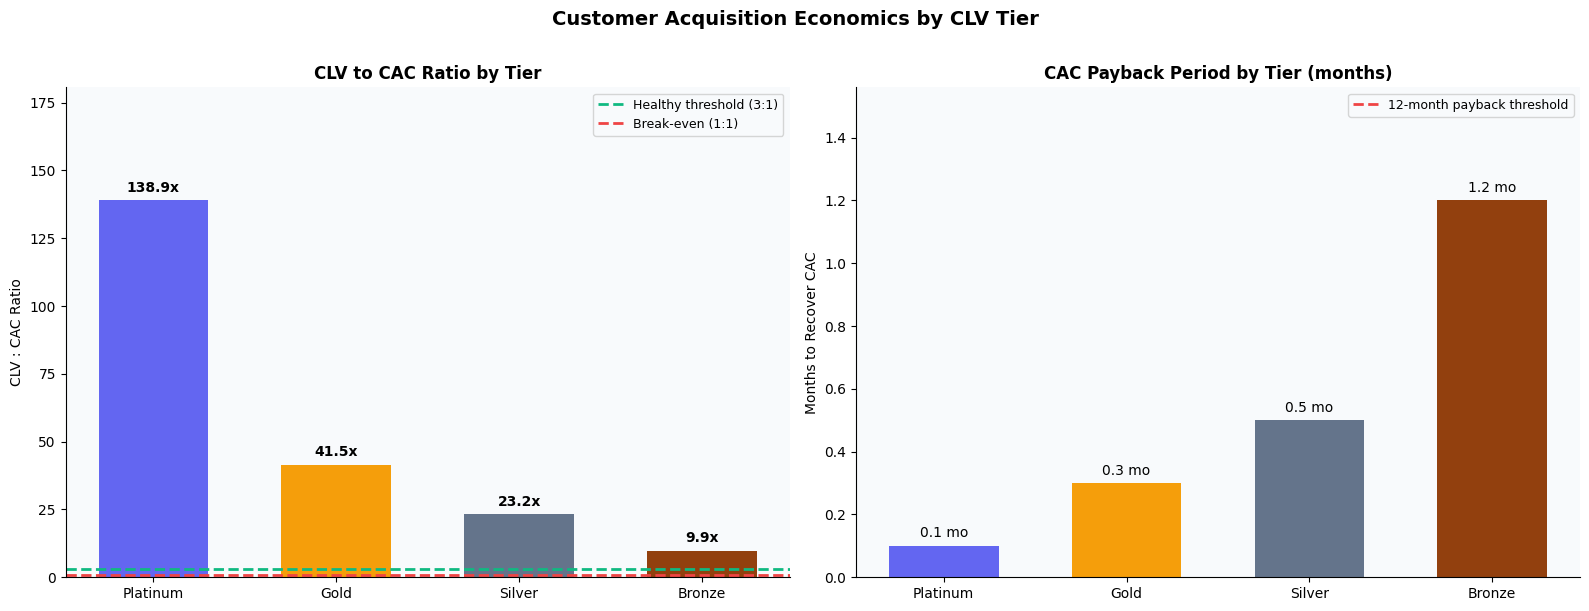

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

tier_c = [tier_colors[t] for t in cac_analysis['tier']]

# CLV to CAC ratio
bars1 = axes[0].bar(
    cac_analysis['tier'], cac_analysis['clv_to_cac'],
    color=tier_c, edgecolor='none', width=0.6
)
axes[0].axhline(3, color=C['good'], linestyle='--',
                linewidth=2, label='Healthy threshold (3:1)')
axes[0].axhline(1, color=C['risk'], linestyle='--',
                linewidth=2, label='Break-even (1:1)')
axes[0].set_title('CLV to CAC Ratio by Tier', fontweight='bold')
axes[0].set_ylabel('CLV : CAC Ratio')
axes[0].bar_label(bars1, fmt='%.1fx', padding=4, fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_facecolor(C['bg'])
axes[0].set_ylim(0, cac_analysis['clv_to_cac'].max() * 1.3)

# Payback period
bars2 = axes[1].bar(
    cac_analysis['tier'], cac_analysis['payback_months'],
    color=tier_c, edgecolor='none', width=0.6
)
axes[1].axhline(12, color=C['risk'], linestyle='--',
                linewidth=2, label='12-month payback threshold')
axes[1].set_title('CAC Payback Period by Tier (months)', fontweight='bold')
axes[1].set_ylabel('Months to Recover CAC')
axes[1].bar_label(bars2, fmt='%.1f mo', padding=4, fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_facecolor(C['bg'])
axes[1].set_ylim(0, cac_analysis['payback_months'].max() * 1.3)

plt.suptitle('Customer Acquisition Economics by CLV Tier',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/output/cac_analysis.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 8: Executive Summary Dashboard

In [19]:
total_clv       = clv_df['historical_clv'].sum()
avg_clv         = clv_df['historical_clv'].mean()
median_clv      = clv_df['historical_clv'].median()
platinum_count  = (clv_df['tier'] == 'Platinum').sum()
platinum_share  = tier_summary.loc['Platinum', 'clv_share_%']
best_ratio_tier = cac_analysis.loc[cac_analysis['clv_to_cac'].idxmax(), 'tier']
best_ratio_val  = cac_analysis['clv_to_cac'].max()

kpis = [
    ('Total Historical CLV', f'GBP {total_clv/1e6:.2f}M',    'all UK customers combined',         C['platinum']),
    ('Avg CLV per Customer', f'GBP {avg_clv:,.0f}',           'mean lifetime spend',               C['gold']),
    ('Median CLV',           f'GBP {median_clv:,.0f}',        'typical customer value',            C['primary']),
    ('Platinum Customers',   f'{platinum_count:,}',            f'{platinum_share:.1f}% of CLV',     C['platinum']),
    ('Gini Coefficient',     f'{gini:.3f}',                   'CLV concentration (0=equal, 1=max)', C['gold']),
    ('Best CLV:CAC Tier',    best_ratio_tier,                  f'{best_ratio_val:.1f}:1 ratio',     C['good']),
]

COLS, ROWS = 3, 2
fig = go.Figure()
fig.update_layout(
    width=880, height=350,
    paper_bgcolor='#0F172A',
    plot_bgcolor='#0F172A',
    margin=dict(l=16, r=16, t=60, b=16),
    title=dict(
        text='Customer Lifetime Value | Executive Summary',
        font=dict(size=15, color='white'),
        x=0.5, xanchor='center', y=0.97,
    ),
    xaxis=dict(visible=False, range=[0, COLS]),
    yaxis=dict(visible=False, range=[0, ROWS]),
)
for i, (label, value, sub, color) in enumerate(kpis):
    col = i % COLS
    row = ROWS - 1 - (i // COLS)
    cx, cy = col + 0.5, row + 0.5
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.06, y1=row+0.94,
        fillcolor='#1E293B', line=dict(color=color, width=1.5), layer='below')
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.84, y1=row+0.94,
        fillcolor=color, line=dict(width=0), layer='above')
    fig.add_annotation(x=cx, y=cy+0.18, text=label.upper(),
        showarrow=False, font=dict(size=9, color='#94A3B8'), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.02, text=f'<b>{value}</b>',
        showarrow=False, font=dict(size=17, color=color), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.24, text=sub,
        showarrow=False, font=dict(size=8.5, color='#64748B'), xanchor='center')
fig.show()


---
## Section 9: Findings and Recommendations

### Key Findings

| Finding | Evidence |
|---------|----------|
| CLV is highly concentrated: top 10% of customers generate a disproportionate share of total value | Lorenz curve and Gini coefficient |
| The gap between mean and median CLV is significant, indicating a long right tail | Distribution chart |
| Not all tiers have healthy CLV-to-CAC ratios | CAC analysis |
| Recency and frequency are strong predictors of CLV | Predictive model features |
| Platinum customers have a much higher payback on acquisition investment | CAC payback chart |

---

### Recommendations

**1. Protect the Platinum Tier at All Costs**

The Lorenz curve shows that a small percentage of customers generate a disproportionate share of total CLV. Any churn in the Platinum tier has an outsized impact on total revenue. These customers deserve personalised retention investment that would be economically unjustifiable for lower tiers.

**2. Use CLV-to-CAC as Your Primary Acquisition Metric**

Replace cost-per-acquisition with CLV-to-CAC in all marketing performance reports. A campaign with a high CPA but targeting future Platinum customers may be your best-performing campaign. A cheap acquisition campaign filling the Bronze tier may be losing money.

**3. Apply the Predictive Model to New Customers Early**

The predictive CLV model can be applied after a customer's first three purchases to estimate their lifetime tier. This allows the business to begin applying the right retention strategy early, before a high-value customer goes dormant through neglect.

**4. Investigate the Long Right Tail**

The Gini coefficient reveals significant CLV inequality. Understanding what behavioural and demographic factors drive the top of that tail is the highest-value analytical question this data can answer next.

---

*Built by Jessica Dan-Odhomo - [LinkedIn](https://www.linkedin.com/in/jessica-dan-odhomo) - [GitHub](https://github.com/Teekaayyy)*
